# Финальный проект: вариант 2

## Задание 1. A/B–тестирование

1.1. Проводится A/B–тестирование.

- У тестовой группы - новая механика оплаты услуг на сайте
- У контрольной группы - базовая механика.

Необходимо сделать вывод по итогу эксперимента: стоит ли запускать новую механику оплаты.

## 1.2. Данные

- groups.csv – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа) 
- groups_add.csv – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных
- active_studs.csv – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента. 
- checks.csv – файл с информацией об оплатах пользователей в дни проведения эксперимента. 

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

In [76]:
gab = pd.read_csv('groups.csv', sep=';')
gab
# принадлежность к контрольной или экспериментальной группе

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A
...,...,...
74479,5692459,B
74480,5692572,B
74481,5692865,B
74482,5693667,B


In [77]:
gab_new = pd.read_csv('groups_add.csv', sep=',')
gab_new

# новые пользователи

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B
...,...,...
87,200247820,B
88,201032527,B
89,201067612,B
90,201067653,B


In [78]:
active_users = pd.read_csv('active_studs.csv')
active_users

# пользователи, которые зашли на платформу в дни эксперимента

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369
...,...
8336,1794344
8337,296883
8338,3598448
8339,3610547


In [79]:
checks_df = pd.read_csv('checks.csv', sep=';')
checks_df

# информация об оплатах пользователей по их id

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0
...,...,...
536,5645737,1900.0
537,5651566,1900.0
538,5662322,1900.0
539,5681918,1900.0


In [80]:
checks_df.dtypes 
# посмотрели тип переменной rev на будущее

student_id      int64
rev           float64
dtype: object

In [81]:
checks_df.isna().sum()

# проверка на наличие пропусков
# в этой таблице только те пользователи, которые совершили покупку в дни эксперимента

student_id    0
rev           0
dtype: int64

In [82]:
checks_df.nunique()

# таблица содержит 541 уникальных id
# 541 пользователь совершил покупку в дни эксперимента

student_id    541
rev            39
dtype: int64

In [83]:
active_users.nunique()

# всего 8341 были активны на сайте в дни эксперимента, возможно просматривали предложения
# то есть не все пользователи сделали покупки в эти дни

student_id    8341
dtype: int64

## 1.3. Предварительная подготовка данных

Сделаем первый анализ без расчета метрик. Таким образом, просто возьмем пользователей, которые в итоге сделали покупки. Этот способ покажет, повлиял ли новый механизм оплаты на сумму, которые пользователи потратили, потратили ли они больше.

In [84]:
# объединяем первые 2 таблицы (gab + gab_new), чтобы добавить новых пользоателей

gab_id = pd.concat([gab, gab_new])

In [85]:
gab_id.shape

(74576, 2)

In [86]:
gab_id.nunique()

# всего 74576 пользователей у сайта в общей сложности (не все были активны в дни проведения эксперимента)

id     74576
grp        2
dtype: int64

In [87]:
active_users = active_users.rename(columns={'student_id': 'id'})

# переименуем, чтобы можно было объединить таблицы

In [88]:
checks_df = checks_df.rename(columns={'student_id': 'id'})

In [89]:
checks_df.shape 

# информация по расходам в дни эксперимента

(541, 2)

### Расчет метрик

In [90]:
all_users = gab_id.merge(active_users, on='id', how='left')
all_users

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A
...,...,...
74571,200247820,B
74572,201032527,B
74573,201067612,B
74574,201067653,B


In [91]:
all_users['is_active'] = all_users['id'].isin(active_users['id']).astype(int)

# создаем столбец для бинарной переменной, где учитывается, активен ли был пользователь в дни проведения эксперимента

In [92]:
all_info = all_users.merge(checks_df, on='id', how='left')
all_info

# все пользователи, вкючая тех, кто совершил оплату с суммой оплаты 

,id,grp,is_active,rev
0,1489,B,0,NaN
1,1627,A,1,990.0
2,1768,B,0,NaN
3,1783,B,0,NaN
4,1794,A,0,NaN
...,...,...,...,...
74571,200247820,B,0,NaN
74572,201032527,B,0,NaN
74573,201067612,B,0,NaN
74574,201067653,B,0,NaN


In [93]:
all_info.query('is_active == 1').grp.value_counts(normalize=True)

# больше активных пользователей экспериментальной группы

B    0.81561
A    0.18439
Name: grp, dtype: float64

In [94]:
# общее количество пользователей

number_users = all_info.id.count()

In [95]:
active = all_info.query('is_active == 1').grp.value_counts().to_frame()

In [96]:
active['share'] = active['grp'] / number_users
active

# доля активных клиентов от общего кол-ва пользователей в каждой группе 

,grp,share
B,6803,0.091222
A,1538,0.020623


In [97]:
revenue = all_info.rev.sum()

# выручка за эти дни

In [98]:
all_info['share_of_revenue'] = all_info['rev'] / revenue 
all_info

,id,grp,is_active,rev,share_of_revenue
0,1489,B,0,NaN,NaN
1,1627,A,1,990.0,0.001727
2,1768,B,0,NaN,NaN
3,1783,B,0,NaN,NaN
4,1794,A,0,NaN,NaN
...,...,...,...,...,...
74571,200247820,B,0,NaN,NaN
74572,201032527,B,0,NaN,NaN
74573,201067612,B,0,NaN,NaN
74574,201067653,B,0,NaN,NaN


In [99]:
all_info['is_purchased'] = all_info['rev'].notna().astype(int)

# создаем столбец для бинарной перменной, где учитывается, совершил ли пользователь покупку

#### Проверка на баги

Проверим данные на наличие ошибок. Например, были ли такие пользователи, которые не были активны в дни эксперимента, но в таблице есть данные об их покупках. Таких записей 149. 

In [100]:
error = all_info.query('is_active == 0 & rev.notna()')

In [101]:
all_info = all_info.drop(error.index)

# удалим эти строки из датасета

In [102]:
all_info

,id,grp,is_active,rev,share_of_revenue,is_purchased
0,1489,B,0,NaN,NaN,0
1,1627,A,1,990.0,0.001727,1
2,1768,B,0,NaN,NaN,0
3,1783,B,0,NaN,NaN,0
4,1794,A,0,NaN,NaN,0
...,...,...,...,...,...,...
74571,200247820,B,0,NaN,NaN,0
74572,201032527,B,0,NaN,NaN,0
74573,201067612,B,0,NaN,NaN,0
74574,201067653,B,0,NaN,NaN,0


In [103]:
# проверим на наличие дубликатов в id
# дубликаты отсутствуют

all_info.duplicated(subset=['id'], keep=False).sum()

0

In [104]:
all_info['id'].nunique()

# второй способ проверки на дубликаты
# все id уникальные

74427

#### Метрики по группам

В следующем шаге создам таблицу, которая будет содержать общее количество пользователей, общее количество активных пользователей, кол-во осуществивших покупку пользователей, общую сумму покупок по каждой из групп. Таким образом, после проведения тестов о наличии или отсутствии статистически значимых различий можно будет сравнить и сделать вывод о том, как повлиял новый механизм оплаты.

In [105]:
# делаем таблицу по группам, чтобы их можно было сравнить

grp_ab = all_info.groupby('grp').agg(
    total_users=('id', 'count'),
    active_users=('is_active', 'sum'),
    purchasers=('is_purchased', 'sum'),
    total_rev=('rev', 'sum')
).reset_index()

grp_ab

,grp,total_users,active_users,purchasers,total_rev
0,A,14664,1538,78,72820.0000
1,B,59763,6803,314,394974.0035


In [106]:
grp_ab['conversion_rate'] = grp_ab.purchasers / grp_ab.active_users
grp_ab

,grp,total_users,active_users,purchasers,total_rev,conversion_rate
0,A,14664,1538,78,72820.0000,0.050715
1,B,59763,6803,314,394974.0035,0.046156


In [107]:
grp_ab['ARPPU'] = grp_ab.total_rev / grp_ab.purchasers
grp_ab

# средний чек на заплатившего пользователя - ARPPU

,grp,total_users,active_users,purchasers,total_rev,conversion_rate,ARPPU
0,A,14664,1538,78,72820.0000,0.050715,933.589744
1,B,59763,6803,314,394974.0035,0.046156,1257.878992


In [108]:
grp_ab['ARPAU'] = grp_ab.total_rev / grp_ab.active_users
grp_ab 

# средняя выручка от одного активного пользователя

,grp,total_users,active_users,purchasers,total_rev,conversion_rate,ARPPU,ARPAU
0,A,14664,1538,78,72820.0000,0.050715,933.589744,47.347204
1,B,59763,6803,314,394974.0035,0.046156,1257.878992,58.058798


In [109]:
grp_ab['activity_rate'] = grp_ab.active_users / grp_ab.total_users
grp_ab

# доля активных пользователей из общего количества пользователей

,grp,total_users,active_users,purchasers,total_rev,conversion_rate,ARPPU,ARPAU,activity_rate
0,A,14664,1538,78,72820.0000,0.050715,933.589744,47.347204,0.104883
1,B,59763,6803,314,394974.0035,0.046156,1257.878992,58.058798,0.113833


Из анализа различий выше (см. статистический тест № 1):
- Показатель ARPPU (средний чек на платящего пользователя) между контрольной и экспериментальной группами значимо различается. 
- ARPPU в экспериментальной группе статистически значимо выше. То есть платящие клиенты потратили больше при новом механизме оплаты.

## 1.4 Проведение A/B тестирования

### Статистический тест № 1

- Сначала проверим, в результате введения новой механики оплаты изменилась ли значимо сумма, которую тратят на покупку услуг клиенты, стали ли они покупать больше.
- Смотрим именно на клиентов, которые сделали покупки (is_purchased = 1)

#### Проверка на нормальность

Group A - контрольная группа

- H0: ГС, из которого взята выборка, распределено нормально
- H1: ГС, из которого взята выборка, распределено не нормально

In [110]:
purchasers_only = all_info.query('is_purchased == 1')

# отберем только активных в дни эксперимента пользователей

In [111]:
control = purchasers_only.query("grp == 'A'")['rev']

In [112]:
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

In [113]:
pg.normality(control, method='normaltest')

,W,pval,normal
rev,30.37842,2.531687e-07,False


Group B - экспериментальная группа

Количество наблюдений превышает 50, поэтому проведем тест Д'Агостино-Пирсона.

In [114]:
test = purchasers_only.query("grp == 'B'")['rev']

In [115]:
pg.normality(test, method='normaltest')

,W,pval,normal
rev,6.795663,0.033446,False


Для обеих групп распределения отличаются от нормального. p-value ниже 0.05, нулевая гипотеза отвергается.

#### Проверка равенства дисперсий

Так как есть явные различия в размере выборок, может возникнуть проблема различий в дисперсиях. Проведу тест Левена.

- H0: дисперсии не различаются
- H1: дисперсии различаются

In [116]:
pg.homoscedasticity(data=purchasers_only, dv="rev", group="grp")

,W,pval,equal_var
levene,3.075682,0.080257,True


Вывод: нулевая гипотеза не отклоняется: p-value превышает значение 0,05. Значит, различия в дисперсиях отсутствуют.

#### Сравнение групп

Сравниваю две независимые выборки, которые распределены не нормально. Проведу тест Колмогорова-Смирнова для проверки на равенство распределений. 

- H0: распределения суммы покупок контрольной и экспериментальной групп по покупающим пользователям совпадают
- H1: распределения суммы покупок контрольной и экспериментальной групп по покупающим пользователям различаются

In [117]:
st.ks_2samp(control.dropna(), test.dropna(), alternative='greater')

KstestResult(statistic=0.323942511840601, pvalue=1.199131957452882e-06, statistic_location=1830.0, statistic_sign=1)

Нулевая гипотеза отклоняется: p-value ниже значения 0,05. Значит, распределения сумм покупок контрольной и экспериментальной групп по совершившим покупки пользователям статистически значимо различаются. 

In [118]:
purchasers_only.groupby('grp').agg({'rev': ['mean', 'median']})

# посмотрим на различия между группами

rev        
            mean  median
grp                     
A     933.589744   585.0
B    1257.878992  1140.0

Первый анализ показал, что:
- Распределения сумм покупок в контрольной и экспериментальной группах различаются.
- В экспериментальной группе оплата услуг в среднем (и по медиане) была выше, то есть пользователи из экспериментальной группы стали больше приобретать услуг, что нам, как продавцам, нужно.
- Механизм, который был внедрен, повлиял на оплату услуг в положительную сторону. 

### Тест хи-квадрат: статистический тест № 2

In [119]:
contingency = pd.crosstab(all_info[all_info['is_active'] == 1]['grp'],
                          all_info[all_info['is_active'] == 1]['is_purchased'])

contingency

# создаем таблицу сопряженности с количеством активных пользователей
# две категориальные переменные: группы и факт совершения покупки

is_purchased,0,1
grp,,
A,1460,78
B,6489,314


In [120]:
import plotly.express as px

In [121]:
fig = px.histogram(all_info.query('is_active == 1')[['grp', 'is_purchased']].dropna(), x='grp', 
                   color='is_purchased')
fig.show()

Есть две категориальные переменные → нужен тест хи-квадрат

- H0: взаимосвязи между переменными нет 
- H1: взаимосвязь есть

In [122]:
from scipy.stats import chi2_contingency

stat, p, dof, expected = chi2_contingency(contingency)

In [123]:
stat, p

(0.48480826522557896, 0.48625240457231045)

Полученный p-value выше 0,05, следовательно нулевая гипотеза не отклоняется. Отсутствует статистически значимая взаимосвязь между переменными: между группой, к которой принадлежит пользователь, и фактом того, совершил он покупку или нет.

Обращая внимание на conversion rate, которая показывает долю совершивших покупку от всех активных клиентов и сравнивается в таблице grp_ab, в группе A (где не был введен механизм) конверсия выше. Тем не менее, мы получили, что нет значимой связи между фактом покупки и фактом принадлежности к группе.

### Статистический тест № 3

Здесь сделаем фильтр, чтобы отобрать ифнормацию только об активных пользователях в дни проведения эксперимента. Таким образом, датафрейм включает и тех, кто не делал покупок, и тех, кто приобрел услуги. 

In [124]:
active_only = all_info.query('is_active == 1')

In [125]:
active_only['rev'] = active_only['rev'].fillna(0)
active_only['share_of_revenue'] = active_only['share_of_revenue'].fillna(0)

In [126]:
active_only

,id,grp,is_active,rev,share_of_revenue,is_purchased
1,1627,A,1,990.0,0.001727,1
10,2085,B,1,0.0,0.000000,0
12,2215,B,1,0.0,0.000000,0
43,3391,A,1,0.0,0.000000,0
45,3401,B,1,0.0,0.000000,0
...,...,...,...,...,...,...
74543,5760471,B,1,0.0,0.000000,0
74545,5777081,B,1,0.0,0.000000,0
74558,5870856,A,1,0.0,0.000000,0
74561,5945085,B,1,0.0,0.000000,0


Сделали фильтр по активным пользователям (т.е. включая тех, кто не сделал покупки). Сравниваем группы по затратам.

In [127]:
control_gr = active_only.query("grp == 'A'")['rev']

In [128]:
test_gr = active_only.query("grp == 'B'")['rev']

#### Тест на нормальность

In [129]:
pg.normality(data=active_only, dv='rev', group='grp', method='normaltest')

# проверка на нормальность тестом Д'Агостино-Пирсона.

,W,pval,normal
grp,,,
A,2240.595797,0.0,False
B,7797.399212,0.0,False


#### Тест на равенство дисперсий

- H0: дисперсии не различаются
- H1: дисперсии различаются

In [130]:
pg.homoscedasticity(data=active_only, dv='rev', group='grp')

# дисперсии равны
# поправка на неравенство дисперсий не нужна - нулевая гипотеза не отвергается

,W,pval,equal_var
levene,1.501461,0.220481,True


#### Тест на наличие различий между A и B группами

- H0: распределения суммы покупок контрольной и экспериментальной групп по активным пользователям совпадают
- H1: распределения суммы покупок контрольной и экспериментальной групп по активным пользователям различаются

In [142]:
# распределения отличаются от нормального
# проводится тест Колмогорова-Смирнова

st.ks_2samp(control_gr.dropna(), test_gr.dropna(), alternative='greater')

KstestResult(statistic=0.014308974450383035, pvalue=0.5915730860871319, statistic_location=1830.0, statistic_sign=1)

p-value выше 0,05, следовательно, гипотеза не отвергается. Рассматриваемые распределения не отличаются. То есть в результате введения нового механизма оплаты не произошло статистически значимых изменений в том, сколько разные группы покупателей, активных на платформе, решили потратить на покупку.

#### Главные выводы по заданию

1. Введение нового механизма оплаты привело к повышению суммы покупок пользователей, повысился чек (средний чек на платящего пользователя - ARPPU). В этом плане были улучшения после введения изменений. То есть те, кто покупал, потратили больше.
2. В абсолютном выражении количество пользователей, сделавших покупку, во второй группе больше, чем в первой.
3. Тем не менее, тест хи-квадрат не показал наличие значимой взаимосвязи между принадлежностью к группе (A или B) и фактом совершения покупки. При сравнении групп видим, что конверсия в покупку была ниже в экспериментальной группе. Конверсия в результате введения нового механизма оплаты стала ниже, но эта различие незначимо, так как тест показал отсутствие взаимосвязи. 
4. Не значимы различия между группами по метрике ARPAU (средняя выручка на одного активного пользователя). То есть активные пользователи не стали тратить больше (или меньше) после изменений.

Таким образом, мы видим, что в новый механизм оплаты значимо повлиял на то, какую сумму платящие пользователи потратили. В экспериментальной группе они тратили больше. Других изменений не наблюдается, но и хуже не стало. То есть можно распространить механизм на всех пользователей.

## Задание 3. Python

1. Реализуйте функцию, которая будет автоматически подгружать информацию из дополнительного файла groups_add.csv (заголовки могут отличаться) и на основании дополнительных параметров пересчитывать метрики.

Чтобы построить единую функцию, буду строить несколько подготовительных.

В задании говорится, что мы подгружаем новые данные о дополнительных пользователях. Но тогда у нас уже должна быть объединенная таблица из трех других, чтобы после добавления данных о новых пользователях можно было считать метрики и в одной функции.

То есть предполагается, что мы работаем с таблицей, считаем там метрики, но потом добавляется информация о новых пользователях.

In [132]:
def merging_tables(groups_csv, active_csv, checks_csv):
    gab = pd.read_csv(groups_csv, sep=None) 
    active_users = pd.read_csv(active_csv, sep=None) 
    checks_df = pd.read_csv(checks_csv, sep=None) 
    
    # Имя первого столбца в первой таблице
    key_col = gab.columns[0]

    # Переименование первого столбца во второй таблице
    if active_users.columns[0] != key_col:
        active_users = active_users.rename(columns={active_users.columns[0]: key_col})

    # Переименование первого столбца в третьей таблице
    if checks_df.columns[0] != key_col:
        checks_df = checks_df.rename(columns={checks_df.columns[0]: key_col})
        
    
    all_users_df = gab.merge(active_users, on='id', how='left')\
        .merge(checks_df, on='id', how='left')
    # нужно оставить всех пользователей из первой таблицы 
    
    all_users_df['is_active'] = all_users_df['id'].isin(active_users['id']).astype(int)
    # столбец с бинарной переменной активности пользователя
    
    return (all_users_df)

In [133]:
# функция, которая будет менять названия на соответствующие исходной таблице в случае несовпадения

def rename_columns(add_df):
    new_ids = pd.read_csv(add_df, sep=None) 
    # мы наверняка не знаем, какой будет разделитель, то None позволит сделать так, что разделитель угадает pandas
    
    column_names = {}  
    # словарь, где ключ - старое название, а содержимое - новое название
    for index, column in enumerate(new_ids.columns):
        new_name = gab.columns[index] 
        # предполагаю, что в дополнительной таблице порядок такой же, как и в исходной
        # что структура их едина
        column_names[column] = new_name
    new_ids = new_ids.rename(columns=column_names)
    return (new_ids)

In [134]:
# это функция сразу создает новый столбец с бинарной переменной is_active
# проверяется, активен ли был пользователь в дни эксперимента
# таким образом, слоедующая функция не перегружается
# iloc вместо названия столбца используется, так как названия для id отличаются
# просто берем первый столбец

def is_active(groups_df):
    active_users = pd.read_csv('active_studs.csv', sep=None)
    
    groups_df['is_active'] = groups_df.iloc[:, [0]].isin(active_users.iloc[:, [0]]).astype(int)
    
    
    return groups_df

In [135]:
# функция, которая добавляет новую информацию о пользователях
# итог - информация обо всех пользователях, о том, совершили ли они покупку, были ли активны

def new_ids_processing(groups_existing_df, add_df):
    
    new_ids = pd.read_csv(add_df, sep=None) 
    
    # этап переименования (аналогично ранним функциям)
    column_names = {} 
    for index, column in enumerate(new_ids.columns):
        new_name = gab.columns[index] 
        # предполагаю, что в дополнительной таблице порядок такой же, как и в исходной
        # что структура их едина
        column_names[column] = new_name
    new_ids = new_ids.rename(columns=column_names)
    
    new_ids = is_active(new_ids)
    # применение ранее созданной функции для создания столбца is_active
    
    groups_all = pd.concat([groups_existing_df, new_ids])
    
    groups_all['is_purchased'] = groups_all['rev'].notna().astype(int)
    # бинарная переменная, которая фиксирует, осуществил ли пользователь покупку
    
    return (groups_all)

In [136]:
# данная функция охватывает все шаги, начиная с подгрузки новых данных к таблице
# конечный результат - таблица сопряженности с метриками
def new_ids_crosstab(groups_existing_df, add_df):
    
    new_ids = pd.read_csv(add_df, sep=None) 
    
    column_names = {}
    for index, column in enumerate(new_ids.columns):
        new_name = gab.columns[index] 
        # предполагаю, что в дополнительной таблице порядок такой же, как и в исходной
        # что структура их едина
        column_names[column] = new_name
    new_ids = new_ids.rename(columns=column_names)
    
    new_ids = is_active(new_ids)
    # применение ранее созданной функции для создания столбца is_active
    
    groups_all = pd.concat([groups_existing_df, new_ids])
    
    groups_all['is_purchased'] = groups_all['rev'].notna().astype(int)
    # бинарная переменная, которая фиксирует, осуществил ли пользователь покупку
    
    # создание таблицы сопряженности по группам с метриками
    grp_ab = groups_all.groupby('grp').agg(total_users=('id', 'count'), 
                                           active_users=('is_active', 'sum'),
                                           purchasers=('is_purchased', 'sum'),
                                           total_rev=('rev', 'sum')).reset_index()
    
    grp_ab['conversion_rate'] = grp_ab.purchasers / grp_ab.active_users
    grp_ab['ARPPU'] = grp_ab.total_rev / grp_ab.purchasers
    grp_ab['ARPAU'] = grp_ab.total_rev / grp_ab.active_users
    grp_ab['activity_rate'] = grp_ab.active_users / grp_ab.total_users
    
    return (grp_ab)

In [137]:
first_table = merging_tables('groups.csv', 'active_studs.csv', 'checks.csv')
first_table

,id,grp,rev,is_active
0,1489,B,NaN,0
1,1627,A,990.0,1
2,1768,B,NaN,0
3,1783,B,NaN,0
4,1794,A,NaN,0
...,...,...,...,...
74479,5692459,B,NaN,0
74480,5692572,B,NaN,0
74481,5692865,B,NaN,0
74482,5693667,B,NaN,0


In [138]:
new_ids_processing(first_table, 'groups_add.csv')

# проверка работы функции

,id,grp,rev,is_active,is_purchased
0,1489,B,NaN,0,0
1,1627,A,990.0,1,1
2,1768,B,NaN,0,0
3,1783,B,NaN,0,0
4,1794,A,NaN,0,0
...,...,...,...,...,...
87,200247820,B,NaN,0,0
88,201032527,B,NaN,0,0
89,201067612,B,NaN,0,0
90,201067653,B,NaN,0,0


2. Реализуйте функцию, которая будет строить графики по получаемым метрикам.

Какие графики можно построить:
- для всех метрик по группам (conversion rate, ARPPU, ARPAU, доле активных пользователей по группам) можно построить столбчатые диаграммы
- по выручке, чтобы сравнить по группам, можно сделать ящики с усами. На них видно и медианные значения, минмум, максимум, значения первого и третьего квартилей.
- можно посмотреть на распределение пользователей, которые сделали покупки, по группам на одном графике

In [139]:
new_ids_crosstab(first_table, 'groups_add.csv')

,grp,total_users,active_users,purchasers,total_rev,conversion_rate,ARPPU,ARPAU,activity_rate
0,A,14693,1535,107,92096.0000,0.069707,860.710280,59.997394,0.104472
1,B,59883,6793,433,479330.0036,0.063742,1106.997699,70.562344,0.113438


In [140]:
def visualizations(ab_table, users_all):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Визуализация метрик', fontsize=16)
    
    # 1. Количество пользователей среди активных, совершивших и не совершивших покупку по группам
    sns.countplot(data=users_all.query('is_active == 1'), x="grp", hue="is_purchased",
                  palette='Spectral', ax=axes[0, 0])
    axes[0, 0].set_title('Сравнение числа совершивших покупку среди активных клиентов')
    axes[0, 0].set_ylabel('Количество клиентов')

    # 2. Доля активных
    sns.barplot(data=ab_table, x='grp', y='activity_rate', palette='Spectral', ax=axes[0, 1])
    axes[0, 1].set_title('Доля активных пользователей')
    axes[0, 1].set_ylabel('Доля')
    axes[0, 1].set_ylim(0, 1)
    

    # 3. Конверсия в покупку
    sns.barplot(data=ab_table, x='grp', y='conversion_rate', palette='Spectral', ax=axes[0, 2])
    axes[0, 2].set_title('Конверсия в покупку')
    axes[0, 2].set_ylabel('conversion rate')
    axes[0, 2].set_ylim(0, 1)
    
    # 4. Распределение выручки (среди клиентов, которые сделали покупку)
    paying = users_all[users_all['rev'].notna()].copy()
    sns.boxplot(data=paying, x='grp', y='rev', ax=axes[1, 0], palette='flare')
    axes[1, 0].set_title('Распределение суммы покупки (платящие)')
    axes[1, 0].set_ylabel('Сумма покупки')

    # 5. ARPPU (средняя выручка на пользователя, сделавшего покупку)
    sns.barplot(data=ab_table, x='grp', y='ARPPU', palette='Spectral', ax=axes[1, 1])
    axes[1, 1].set_title('ARPPU')
    axes[1, 1].set_ylabel('Средняя выручка')
    
    # 3. График распределения по группам по платящим клиентам
    sns.barplot(data=ab_table, x='grp', y='ARPAU', palette='flare', ax=axes[1, 2])
    axes[1, 2].set_title('ARPAU')
    axes[1, 2].set_ylabel('Средняя выручка')

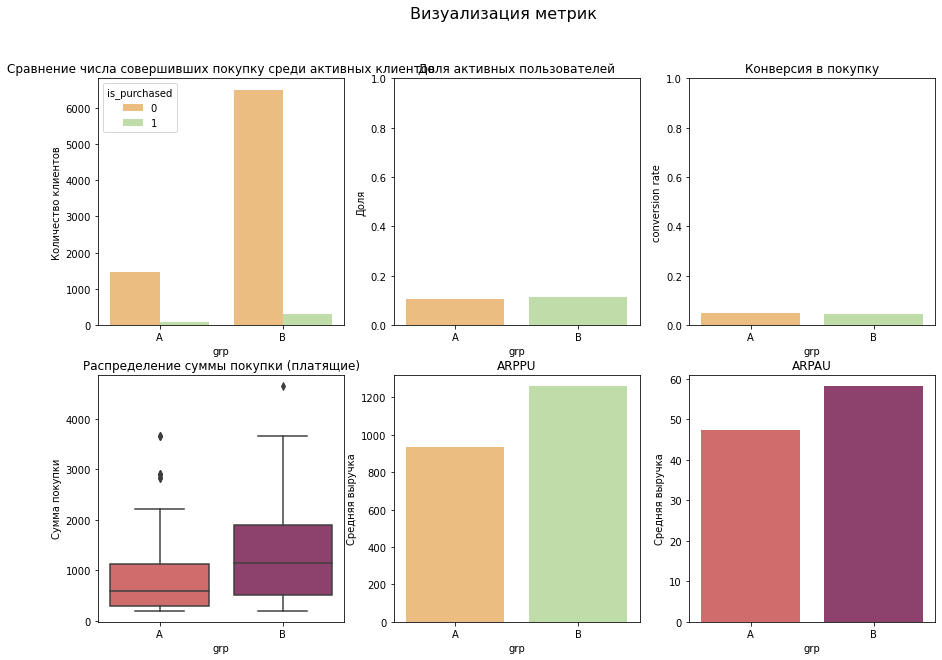

In [141]:
visualizations(grp_ab, all_info)